# Lab 11

## Section 1: PyTorch 



## Import Torch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd 

In [1]:
pip install torch torchvision 

  Using cached torch-2.10.0-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp313-cp313-win_amd64.whl.metadata (5.4 kB)
  Using cached filelock-3.24.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/113.8 MB 726.7 kB/s eta 0:02:36
   ---------------------------------------- 0.5/113.8 MB 726.7 kB/s eta 0:02:36
   ---------------------------------------- 0.5/113.8 MB 726.7 kB/s eta 0:02:36
   ---


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Task 1: GPU/Device Agnostic Code
**Goal:** Write code that runs on CPU, CUDA, or MPS (Mac) automatically.


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')


sample_input = torch.randn(1, 10).to(device)
type(sample_input)

Using device: cpu


torch.Tensor

## Section 2: MNIST Project 
Step 1: What is MNIST & Downloading Data

Concept: MNIST is the "Hello World" of Machine Learning. It contains 70,000 images of handwritten digits (0-9).

The Goal: Teach the computer to look at a grid of pixels and say "That is a 7".

The Data: Each image is grayscale and exactly 28×28


In [4]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [5]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# transform=ToTensor() converts the image (0-255) to a Torch Tensor (0.0-1.0)

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.88MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 96.7kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 368kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


In [6]:
# Do for Testing
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)


## Visualizing One Image & Understanding Shapes

In [11]:
len(training_data)

60000

In [12]:
len(test_data )

10000

In [22]:
img,label=training_data[0]

In [23]:
img.shape

torch.Size([1, 28, 28])

In [24]:
img.squeeze().shape

torch.Size([28, 28])

## Display one Image in MatplotLib

In [25]:
import matplotlib.pyplot as plt

Label: 5


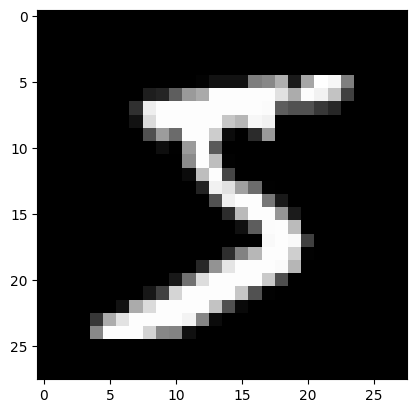

In [28]:
#print image
plt.imshow(img.squeeze(),cmap="gray")
print(f"Label: {label}")


# Calculation for the Input Layer

Concept: We are building a Linear (Feed-Forward) Network,

A Linear Layer consists of neurons in a single vertical line.

Our image is a square grid (28×28).

The Division: We must "cut" the image row by row and stack them into one long line.

The Calculation:

Height×Width=Total Input Features
28×28=784
So, our Input Layer must have 784 neurons.

In [57]:
img, label = training_data[1]

In [59]:
img.squeeze().shape

torch.Size([28, 28])

## The Architecture (1 Input, 1 Hidden, 1 Output
The Concept: We will build the simplest standard network.

Input Layer (784): Receives the pixels.

Hidden Layer (128): The "brain" that learns shapes (loops, lines). We pick 128 because it's enough to learn but not too big.

Output Layer (10): The final decision. We have 10 digits (0-9), so we need 10 output scores.

In [31]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flattern=nn.Flatten()
        
        self.layers=nn.Sequential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
        
        
    def forward(self,x):
            x=self.flattern(x)
            logits=self.layers(x)
            return logits
        
model=SimpleNet()
print(model)

SimpleNet(
  (flattern): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Understanding Batch Size (The Stack)

The Concept: Think of the model like a teacher grading exams.

Batch Size = 1: The teacher grades 1 exam, updates the grade book, then picks up the next exam. (Too slow).

Batch Size = 64: The teacher picks up a stack of 64 exams, grades them all at once, and updates the grade book one time for the whole stack. (Much faster).

We use DataLoader to create these "stacks" for us.

In [33]:
from torch.utils.data import DataLoader

# Create stacks
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
# do for Test_data
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)
print(len(train_loader),"--",len(test_loader))


938 -- 157


## The Training Loop

In [ ]:
#weight update kara nu mechanism
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#loss calc karvanu mechanism
loss_fn = nn.CrossEntropyLoss()

In [37]:
def train(epoch):
    model.train()
    
    for epoch in range(epoch):
        print(f"\nEpoch: {epoch+1}\n")
        for batch_No,(data,target) in enumerate(train_loader):
            output=model(data)
            loss=loss_fn(output,target)
            
            #backpropagation
            optimizer.zero_grad()#clear old gradients
            loss.backward()#calculate new gradients
            optimizer.step()#update weights
            
            if batch_No%100==0:
                print(f"Batch: {batch_No} Loss: {loss.item():.4f}")


In [38]:
train(epoch=3)


Epoch: 1

Batch: 0 Loss: 0.2155
Batch: 100 Loss: 0.1726
Batch: 200 Loss: 0.3989
Batch: 300 Loss: 0.1610
Batch: 400 Loss: 0.3061
Batch: 500 Loss: 0.2195
Batch: 600 Loss: 0.0830
Batch: 700 Loss: 0.0622
Batch: 800 Loss: 0.1790
Batch: 900 Loss: 0.1031

Epoch: 2

Batch: 0 Loss: 0.1547
Batch: 100 Loss: 0.1457
Batch: 200 Loss: 0.0735
Batch: 300 Loss: 0.2010
Batch: 400 Loss: 0.1310
Batch: 500 Loss: 0.0645
Batch: 600 Loss: 0.0677
Batch: 700 Loss: 0.1630
Batch: 800 Loss: 0.1040
Batch: 900 Loss: 0.0318

Epoch: 3

Batch: 0 Loss: 0.0539
Batch: 100 Loss: 0.2017
Batch: 200 Loss: 0.1379
Batch: 300 Loss: 0.1300
Batch: 400 Loss: 0.0106
Batch: 500 Loss: 0.0293
Batch: 600 Loss: 0.0500
Batch: 700 Loss: 0.0878
Batch: 800 Loss: 0.1389
Batch: 900 Loss: 0.0613


In [73]:
train()

Batch 0: Loss = 2.2587
Batch 100: Loss = 0.4718
Batch 200: Loss = 0.2364
Batch 300: Loss = 0.3395
Batch 400: Loss = 0.1946
Batch 500: Loss = 0.3256
Batch 600: Loss = 0.1262
Batch 700: Loss = 0.2901
Batch 800: Loss = 0.4627
Batch 900: Loss = 0.0775


Test Accuracy: 94.6%
